In [1]:
import spacy
import fitz  # pymupdf

# Cargar modelo en español 
try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo...")
    from spacy.cli import download
    download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

# TEXTO DE ENTRADA — extracción correcta desde PDF
doc_pdf = fitz.open("allan_poe.pdf")
texto = " ".join(page.get_text() for page in doc_pdf)
doc_pdf.close()

print(f"Texto cargado con éxito. Longitud: {len(texto)} caracteres.")

# SpaCy tiene un límite de tokens; lo ampliamos para libros largos
nlp.max_length = len(texto) + 10_000

# 1. TOKENIZACIÓN
doc = nlp(texto)

print(f"--- 1. Tokenización (Total tokens: {len(doc)}) ---")
print([token.text for token in doc][:20])

Descargando modelo...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 15.5 MB/s  0:00:00m0:00:010:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Texto cargado con éxito. Longitud: 12377 caracteres.
--- 1. Tokenización (Total tokens: 2732) ---
['El', 'corazón', 'delator', '\n \n', 'Edgar', 'Allan', 'Poe', '\n \n \n \n \n \n \n \n \n \n \n', '¡', 'Es', 'cierto', '!', 'Siempre', 'he', 'sido', 'nervioso', ',', 'muy', 'nervioso', ',']


In [2]:
# 2. FILTRADO DE STOP WORDS
# Separamos lo que aporta valor semántico del "pegamento" gramatical

tokens_relevantes = []
tokens_ruido = []

for token in doc:
    # Filtramos si es stopword o si es puntuación
    if not token.is_stop and not token.is_punct and token.text.strip():
        tokens_relevantes.append(token.text)
    elif token.is_stop:
        tokens_ruido.append(token.text)

print(f"\n--- 2. Filtrado de Stop Words ---")
print(f"Palabras eliminadas (Ruido): {tokens_ruido[:10]}...")
print(f"Palabras conservadas (Contenido): {tokens_relevantes[:10]}...")
print(f"Reducción de tamaño: de {len(doc)} a {len(tokens_relevantes)} tokens.")


--- 2. Filtrado de Stop Words ---
Palabras eliminadas (Ruido): ['El', 'Es', 'cierto', 'Siempre', 'he', 'sido', 'muy', 'Pero', 'por', 'qué']...
Palabras conservadas (Contenido): ['corazón', 'delator', 'Edgar', 'Allan', 'Poe', 'nervioso', 'nervioso', 'terriblemente', 'nervioso', 'afirman']...
Reducción de tamaño: de 2732 a 888 tokens.


In [3]:
# 3. LEMATIZACIÓN Y NORMALIZACIÓN FINAL
# Reducimos las palabras a su raíz (Lema) y estandarizamos a minúsculas
# Objetivo: Que "hablo", "hablaré" y "habla" cuenten como el mismo concepto: "hablar"

tokens_normalizados = []
cambios_interesantes = []

for token in doc:
    # Aplicamos los mismos filtros de calidad que en el paso 2
    if not token.is_stop and not token.is_punct and token.text.strip():
        
        # AQUÍ OCURRE LA MAGIA: 
        # 1. Extraemos el lema (token.lemma_)
        # 2. Convertimos a minúsculas (.lower())
        lema = token.lemma_.lower()
        tokens_normalizados.append(lema)
        
        # Para fines educativos: Guardamos casos donde la palabra cambió drásticamente
        # Ej: "fui" -> "ir"
        if token.text.lower() != lema:
            cambios_interesantes.append(f"{token.text} ➡ {lema}")

print(f"\n--- 3. Lematización y Normalización ---")
print(f"Total de tokens procesados: {len(tokens_normalizados)}")
print(f"Ejemplos de transformaciones (Palabra original ➡ Lema):")
# Mostramos solo los primeros 5 cambios para no saturar la pantalla
print(cambios_interesantes[:10]) 

print(f"\nResultado final (Primeros 10 tokens):")
print(tokens_normalizados[:10])


--- 3. Lematización y Normalización ---
Total de tokens procesados: 888
Ejemplos de transformaciones (Palabra original ➡ Lema):
['afirman ➡ afirmar', 'agudizado ➡ agudizar', 'sentidos ➡ sentido', 'destruirlos ➡ destruir él', 'embotarlos ➡ embotarlo', 'oírse ➡ oir él', 'cosas ➡ cosa', 'observen ➡ observir', 'cuento ➡ contar', 'entró ➡ entrar']

Resultado final (Primeros 10 tokens):
['corazón', 'delator', 'edgar', 'allan', 'poe', 'nervioso', 'nervioso', 'terriblemente', 'nervioso', 'afirmar']


In [4]:
# 4. CONSTRUCCIÓN DEL CORPUS POR ORACIONES

corpus_lematizado = []

for sent in doc.sents:
    tokens_sent = [
        token.lemma_.lower()
        for token in sent
        if not token.is_stop and not token.is_punct and token.text.strip()
    ]
    # Descartamos oraciones demasiado cortas (ruido del PDF: encabezados, etc.)
    if len(tokens_sent) >= 3:
        corpus_lematizado.append(" ".join(tokens_sent))

print(f"--- 4. Corpus construido ---")
print(f"Total de documentos (oraciones): {len(corpus_lematizado)}")
print(f"\nEjemplos:")
for i, oracion in enumerate(corpus_lematizado[:3]):
    print(f"  [{i}] {oracion}")

--- 4. Corpus construido ---
Total de documentos (oraciones): 112

Ejemplos:
  [0] corazón delator edgar allan poe
  [1] nervioso nervioso terriblemente nervioso
  [2] enfermedad agudizar sentido destruir él embotarlo


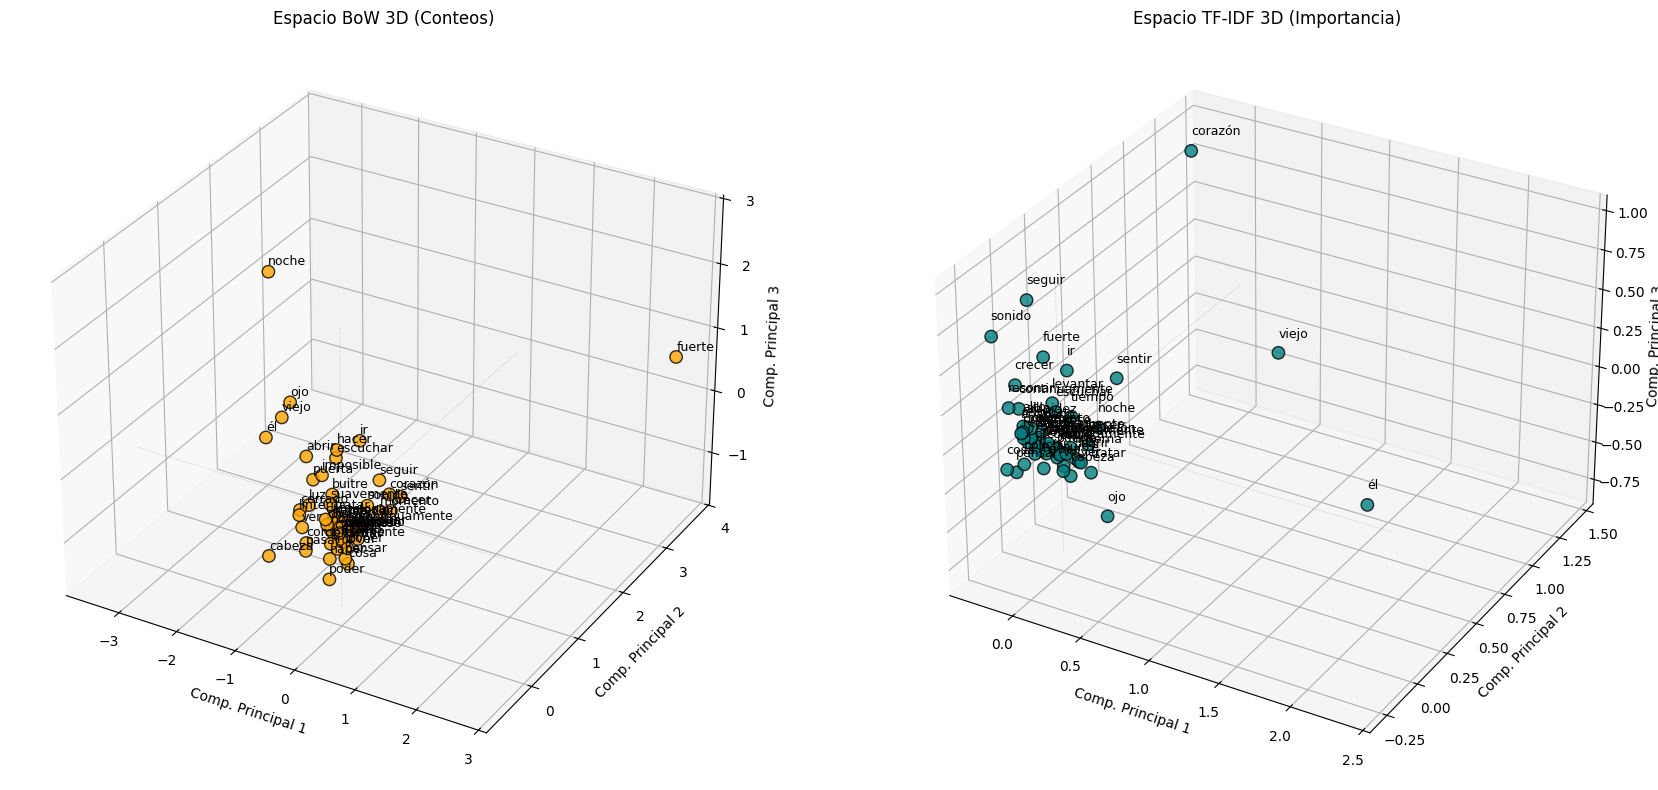

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import necesario para 3D
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------------------------------------
# FUNCIÓN AUXILIAR PARA GRAFICAR EN 3D
# ---------------------------------------------------------
def graficar_palabras_3d(ax, matriz, vocabulario, titulo, color_puntos):
    # 1. TRANSPONER: Filas = Palabras, Columnas = Contextos
    matriz_palabras = matriz.T

    # 2. PCA: Reducir a 3 DIMENSIONES
    pca = PCA(n_components=3)
    coords = pca.fit_transform(matriz_palabras.toarray())

    # Extraer coordenadas X, Y, Z
    x = coords[:, 0]
    y = coords[:, 1]
    z = coords[:, 2]

    # 3. GRAFICAR SCATTER 3D
    ax.scatter(x, y, z, c=color_puntos, s=80, edgecolors='k', alpha=0.8, depthshade=True)

    # Etiquetar puntos
    for i, palabra in enumerate(vocabulario):
        ax.text(x[i], y[i], z[i] + 0.1, palabra, fontsize=9)

    ax.set_title(titulo)
    ax.set_xlabel('Comp. Principal 1')
    ax.set_ylabel('Comp. Principal 2')
    ax.set_zlabel('Comp. Principal 3')

    # Líneas de referencia en el origen (0,0,0)
    ax.plot([0, 0], [0, 0], [z.min(), z.max()], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([x.min(), x.max()], [0, 0], [0, 0], c='grey', ls='--', lw=0.5, alpha=0.3)
    ax.plot([0, 0], [y.min(), y.max()], [0, 0], c='grey', ls='--', lw=0.5, alpha=0.3)


# ---------------------------------------------------------
# CONFIGURACIÓN DE LA FIGURA 3D
# ---------------------------------------------------------
# Limitamos el vocabulario a las 60 palabras más frecuentes para que las
# etiquetas sean legibles y PCA sea estable sobre el vocabulario completo del libro.
MAX_WORDS = 60

fig = plt.figure(figsize=(18, 8))

# --- A. BAG OF WORDS (Izquierda) ---
ax1 = fig.add_subplot(121, projection='3d')

bow_vectorizer = CountVectorizer(max_features=MAX_WORDS)
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
vocab_bow = bow_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax1, X_bow, vocab_bow,
                     "Espacio BoW 3D (Conteos)",
                     "orange")

# --- B. TF-IDF (Derecha) ---
ax2 = fig.add_subplot(122, projection='3d')

tfidf_vectorizer = TfidfVectorizer(max_features=MAX_WORDS)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

graficar_palabras_3d(ax2, X_tfidf, vocab_tfidf,
                     "Espacio TF-IDF 3D (Importancia)",
                     "teal")

plt.tight_layout()
plt.show()

In [6]:
from gensim.models import Word2Vec

# ---------------------------------------------------------
# 6. SEMÁNTICA DISTRIBUCIONAL — WORD2VEC
# ---------------------------------------------------------
# Hipótesis distribucional: "una palabra se conoce por las
# compañías que frecuenta"
# Word2Vec aprende vectores densos donde palabras que aparecen
# en contextos similares quedan cerca en el espacio vectorial.

# El corpus debe ser lista de listas de tokens (no strings)
corpus_w2v = [oracion.split() for oracion in corpus_lematizado]

model_w2v = Word2Vec(
    sentences=corpus_w2v,
    vector_size=100,   # dimensiones del espacio vectorial
    window=5,          # contexto: ±5 palabras alrededor de la objetivo
    min_count=2,       # ignorar palabras que aparecen menos de 2 veces
    workers=4,
    epochs=200,        # más épocas = mejores vectores en corpus pequeños
    seed=42,
)

print(f"--- 6. Word2Vec entrenado ---")
print(f"Vocabulario aprendido: {len(model_w2v.wv)} palabras únicas")

# Exploración semántica: palabras más cercanas a conceptos clave del cuento
for palabra_clave in ["corazón", "nervioso", "viejo", "muerte"]:
    if palabra_clave in model_w2v.wv:
        similares = model_w2v.wv.most_similar(palabra_clave, topn=5)
        print(f"\nMás cercanas a '{palabra_clave}':")
        for palabra, score in similares:
            print(f"  {palabra:<20} similitud={score:.3f}")

--- 6. Word2Vec entrenado ---
Vocabulario aprendido: 154 palabras únicas

Más cercanas a 'corazón':
  entretanto           similitud=0.996
  ahogado              similitud=0.996
  inmóvil              similitud=0.995
  contuve              similitud=0.995
  minuto               similitud=0.995

Más cercanas a 'nervioso':
  menor                similitud=0.933
  tiempo               similitud=0.930
  horror               similitud=0.929
  siquiera             similitud=0.929
  oir                  similitud=0.928

Más cercanas a 'viejo':
  oh                   similitud=0.996
  ver                  similitud=0.995
  hora                 similitud=0.995
  jamás                similitud=0.995
  imposible            similitud=0.995

Más cercanas a 'muerte':
  vecino               similitud=0.993
  vano                 similitud=0.992
  escuchar             similitud=0.992
  pared                similitud=0.992
  sentado              similitud=0.991


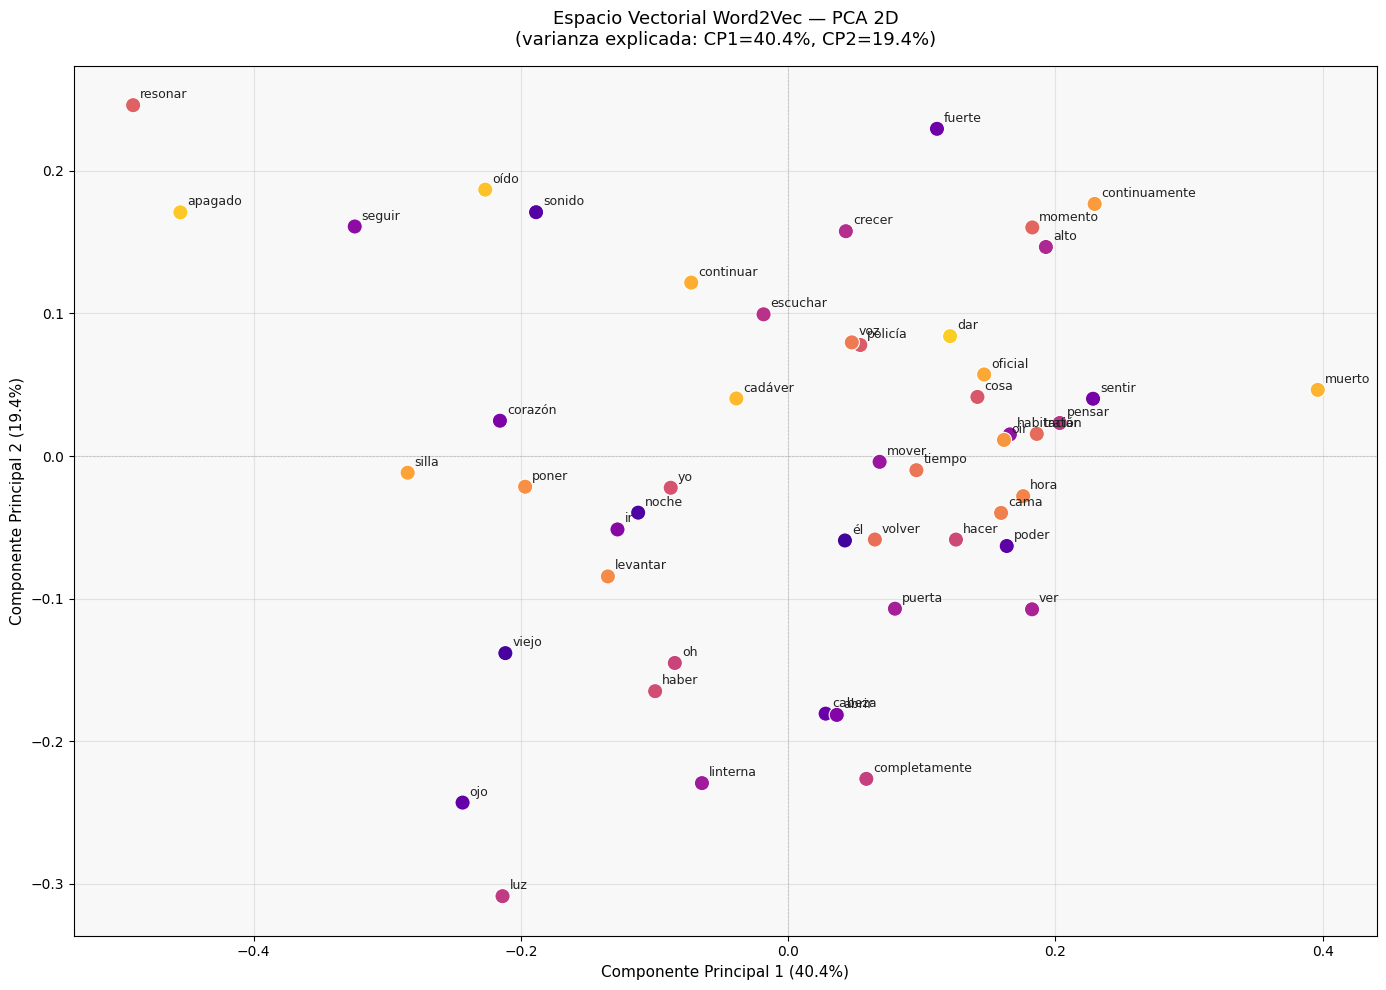

Guardado: word2vec_2d.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
import numpy as np

# ---------------------------------------------------------
# 7. VISUALIZACIÓN 2D — PCA sobre vectores Word2Vec
# ---------------------------------------------------------
# Tomamos las N palabras más frecuentes del vocabulario aprendido
N_PALABRAS = 50
palabras = [w for w, _ in model_w2v.wv.key_to_index.items()][:N_PALABRAS]
vectores = np.array([model_w2v.wv[w] for w in palabras])

# Reducción de 100 → 2 dimensiones
pca2d = PCA(n_components=2, random_state=42)
coords2d = pca2d.fit_transform(vectores)

varianza = pca2d.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#f8f8f8")

# Coloreamos por posición en el vocabulario (frecuencia aproximada)
colores = cm.plasma(np.linspace(0.1, 0.9, N_PALABRAS))
scatter = ax.scatter(coords2d[:, 0], coords2d[:, 1],
                     c=colores, s=120, edgecolors="white", linewidths=0.8, zorder=3)

for i, palabra in enumerate(palabras):
    ax.annotate(
        palabra,
        xy=(coords2d[i, 0], coords2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        color="#222222",
    )

ax.axhline(0, color="grey", lw=0.5, ls="--", alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, ls="--", alpha=0.4)
ax.set_title(
    f"Espacio Vectorial Word2Vec — PCA 2D\n"
    f"(varianza explicada: CP1={varianza[0]:.1f}%, CP2={varianza[1]:.1f}%)",
    fontsize=13, pad=15
)
ax.set_xlabel(f"Componente Principal 1 ({varianza[0]:.1f}%)", fontsize=11)
ax.set_ylabel(f"Componente Principal 2 ({varianza[1]:.1f}%)", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("word2vec_2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: word2vec_2d.png")

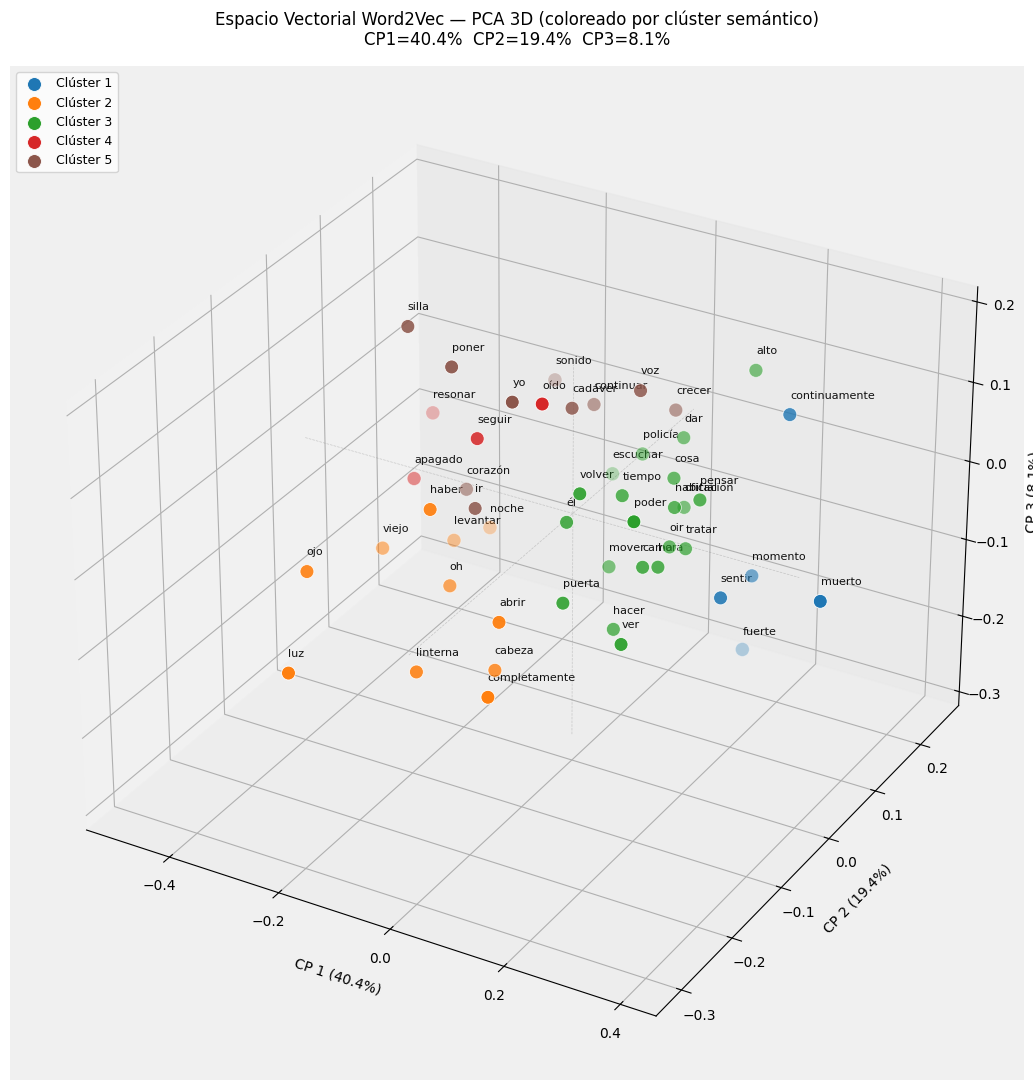

Guardado: word2vec_3d.png


In [8]:
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------------------------------------
# 8. VISUALIZACIÓN 3D — PCA sobre vectores Word2Vec
# ---------------------------------------------------------
# Agrupamos las palabras en clústeres temáticos por similitud coseno
# para dar color semántico a los puntos.
from sklearn.cluster import KMeans

N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
etiquetas = kmeans.fit_predict(vectores)

# Reducción de 100 → 3 dimensiones
pca3d = PCA(n_components=3, random_state=42)
coords3d = pca3d.fit_transform(vectores)

varianza3d = pca3d.explained_variance_ratio_ * 100
x, y, z = coords3d[:, 0], coords3d[:, 1], coords3d[:, 2]

paleta = cm.tab10(np.linspace(0, 0.5, N_CLUSTERS))

fig = plt.figure(figsize=(15, 11))
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#f0f0f0")

for cluster_id in range(N_CLUSTERS):
    mask = etiquetas == cluster_id
    ax.scatter(
        x[mask], y[mask], z[mask],
        c=[paleta[cluster_id]],
        s=100,
        edgecolors="white",
        linewidths=0.6,
        depthshade=True,
        label=f"Clúster {cluster_id + 1}",
        zorder=3,
    )

for i, palabra in enumerate(palabras):
    ax.text(x[i], y[i], z[i] + 0.02, palabra, fontsize=8, color="#111111")

# Ejes de referencia en el origen
ax.plot([0, 0], [0, 0], [z.min(), z.max()], c="grey", ls="--", lw=0.5, alpha=0.35)
ax.plot([x.min(), x.max()], [0, 0], [0, 0], c="grey", ls="--", lw=0.5, alpha=0.35)
ax.plot([0, 0], [y.min(), y.max()], [0, 0], c="grey", ls="--", lw=0.5, alpha=0.35)

ax.set_title(
    f"Espacio Vectorial Word2Vec — PCA 3D (coloreado por clúster semántico)\n"
    f"CP1={varianza3d[0]:.1f}%  CP2={varianza3d[1]:.1f}%  CP3={varianza3d[2]:.1f}%",
    fontsize=12, pad=15
)
ax.set_xlabel(f"CP 1 ({varianza3d[0]:.1f}%)", labelpad=8)
ax.set_ylabel(f"CP 2 ({varianza3d[1]:.1f}%)", labelpad=8)
ax.set_zlabel(f"CP 3 ({varianza3d[2]:.1f}%)", labelpad=8)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("word2vec_3d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: word2vec_3d.png")